#**ACTIVIDAD:**
> **Reconstrucción de la masa invariante de un par de muones.**






## 1. LECTURA Y EXPLORACIÓN DE DATOS

In [ ]:
import pandas as pd

link = "http://opendata.cern.ch/record/307/files/Zmumu.csv"
datos = pd.read_csv(link)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Type    2304 non-null   object 
 1   Run     2304 non-null   int64  
 2   Event   2304 non-null   int64  
 3   E1      2304 non-null   float64
 4   px1     2304 non-null   float64
 5   py1     2304 non-null   float64
 6   pz1     2304 non-null   float64
 7   pt1     2304 non-null   float64
 8   eta1    2304 non-null   float64
 9   phi1    2304 non-null   float64
 10  Q1      2304 non-null   int64  
 11  E2      2304 non-null   float64
 12  px2     2304 non-null   float64
 13  py2     2304 non-null   float64
 14  pz2     2304 non-null   float64
 15  pt2     2304 non-null   float64
 16  eta2    2304 non-null   float64
 17  phi2    2304 non-null   float64
 18  Q2      2304 non-null   int64  
 19  M       2304 non-null   float64
dtypes: float64(15), int64(4), object(1)
memory usage: 360.1+ KB


In [ ]:
datos.describe()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,2304.000000,2.304000e+03,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000,2304.000000
mean,148030.371528,2.879137e+08,58.544376,-0.065653,1.635860,3.848580,37.054403,0.083466,0.129541,0.026042,78.486356,-1.819110,-1.209907,4.912122,40.574535,0.088068,-0.046975,-0.004340,80.205934
std,0.928623,1.923933e+08,39.408903,29.768234,28.384438,57.207160,17.954941,1.112368,1.798447,0.999878,43.183059,31.361292,29.268408,78.475878,14.214757,1.257694,1.845636,1.000208,25.263475
min,148029.000000,7.920200e+05,2.796820,-165.239205,-80.285346,-391.986055,0.730659,-2.414040,-3.140030,-1.000000,4.024605,-165.239205,-80.285346,-391.986055,0.977246,-2.414040,-3.140030,-1.000000,0.389058
25%,148029.000000,1.241126e+08,36.802054,-21.931085,-21.693344,-21.730075,30.389325,-0.681933,-1.408678,-1.000000,47.050415,-27.050008,-27.318892,-44.582209,33.190050,-1.052015,-1.682900,-1.000000,85.042383
50%,148031.000000,2.502024e+08,49.022077,-0.204537,0.942586,3.347750,38.880900,0.118424,0.176324,1.000000,66.316349,-1.530845,-1.047518,4.603336,40.135450,0.111915,-0.070413,-1.000000,90.007098
75%,148031.000000,4.503432e+08,73.428472,23.967105,25.244316,30.169257,45.223475,0.881367,1.766270,1.000000,102.634265,23.898258,23.604443,59.086403,46.004775,1.244790,1.533680,1.000000,91.999604
max,148031.000000,6.574415e+08,409.708437,82.816840,93.797208,193.804803,180.773000,2.423650,3.136440,1.000000,409.708437,83.103055,93.797208,200.009952,180.773000,2.307440,3.136440,1.000000,172.101768


##2. CÁLCULO DE LA MASA INVARIANTE

In [ ]:
import numpy as np

energia_total = datos["E1"] + datos["E2"]# energía total del sistema formado por los dos muones
energia_total.head()

,0
0,142.823741
1,144.546795
2,143.927707
3,142.204653
4,91.587115


In [ ]:
#momento total
px_total = datos["px1"] + datos["px2"]
py_total = datos["py1"] + datos["py2"]
pz_total = datos["pz1"] + datos["pz2"]

print(px_total, py_total, pz_total)

0       -7.050850
1       -6.077238
2       -5.765274
3       -6.738886
4        2.606209
          ...    
2299     2.180599
2300   -35.556521
2301   -35.664423
2302   -36.416644
2303   -36.308742
Length: 2304, dtype: float64 0        1.313719
1        0.862882
2        0.728935
3        1.179772
4        5.682295
          ...    
2299    -0.485691
2300   -24.904497
2301   -24.906442
2302   -25.198995
2303   -25.197050
Length: 2304, dtype: float64 0      -116.391946
1      -117.740208
2      -117.222502
3      -115.874240
4        12.824061
           ...    
2299      6.282360
2300   -227.043391
2301   -226.767449
2302   -228.380034
2303   -228.655976
Length: 2304, dtype: float64


##3. DISTRIBUCIÓN DE MASA

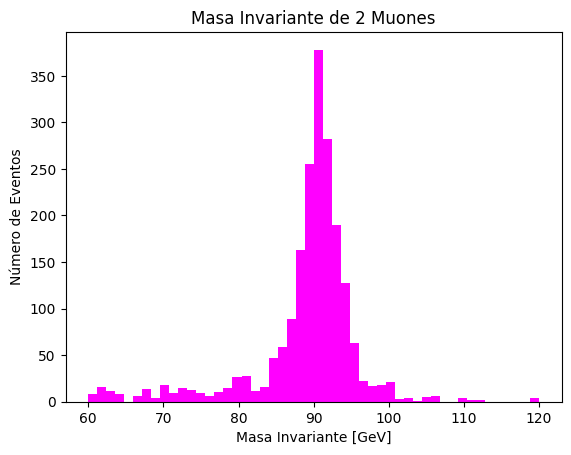

In [ ]:
#formula de la masa invariante
masa_cuadrada = energia_total**2 - px_total**2 - py_total**2 - pz_total**2
masa = np.sqrt(masa_cuadrada) #masa invariante

datos["masa_calculada"] = masa

import matplotlib.pyplot as plt
plt.hist(datos["masa_calculada"], bins=50, range=(60,120), color="magenta")
plt.xlabel("Masa Invariante [GeV]")
plt.ylabel("Número de Eventos")
plt.title("Masa Invariante de 2 Muones")
plt.show()

In [ ]:
#valor máximo aproximado
conteos, limites = np.histogram(datos["masa_calculada"],bins=50,range=(60, 120))
posicion = np.argmax(conteos)
maximo = (limites[posicion] + limites[posicion + 1]) / 2
print("Máximo =", maximo)

Máximo = 90.6


##4. ANÁLISIS DE LAS OTRAS VARIABLES

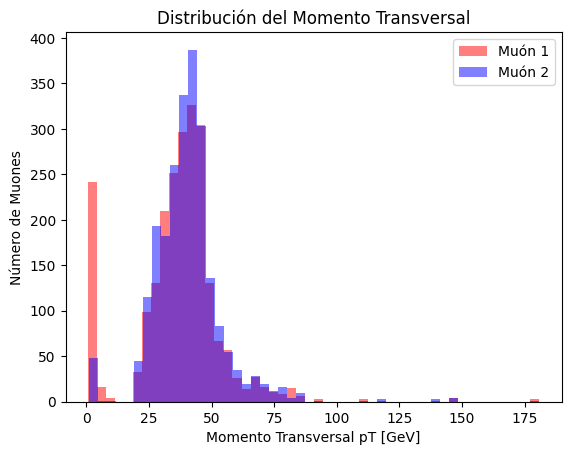

In [ ]:
plt.hist(datos["pt1"], bins=50, alpha=0.5, label="Muón 1", color="red")
plt.hist(datos["pt2"], bins=50, alpha=0.5, label="Muón 2", color="blue")

plt.xlabel("Momento Transversal pT [GeV]")
plt.ylabel("Número de Muones")
plt.title("Distribución del Momento Transversal")
plt.legend()
plt.show()

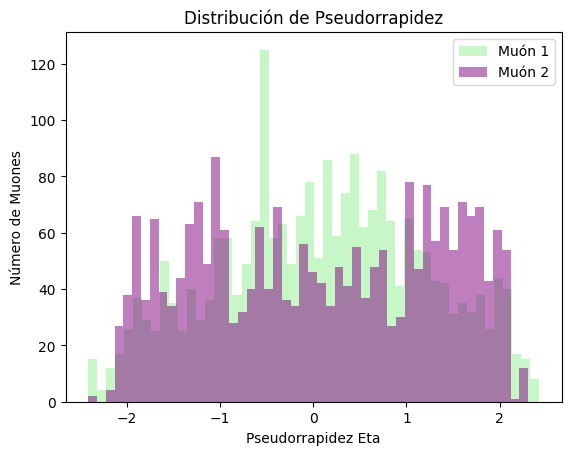

In [ ]:
#pseudorrapidez

plt.hist(datos["eta1"], bins=50, alpha=0.5, label="Muón 1", color="lightgreen")
plt.hist(datos["eta2"], bins=50, alpha=0.5, label="Muón 2",  color="purple")

plt.xlabel("Pseudorrapidez Eta")
plt.ylabel("Número de Muones")
plt.title("Distribución de Pseudorrapidez")
plt.legend()
plt.show()

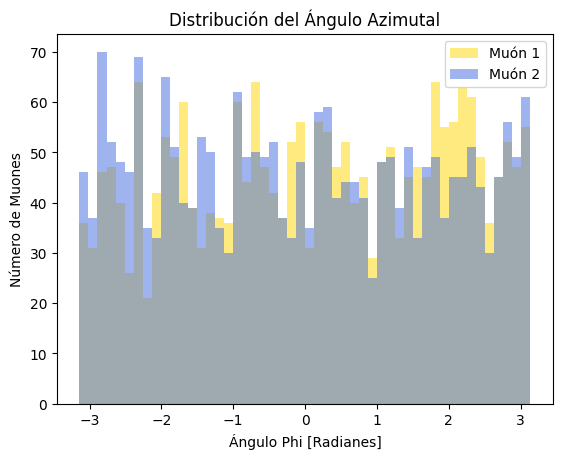

In [ ]:
# phi

plt.hist(datos["phi1"], bins=50, alpha=0.5, label="Muón 1", color="gold")
plt.hist(datos["phi2"], bins=50, alpha=0.5, label="Muón 2", color="royalblue")

plt.xlabel("Ángulo Phi [Radianes]")
plt.ylabel("Número de Muones")
plt.title("Distribución del Ángulo Azimutal")
plt.legend()
plt.show()

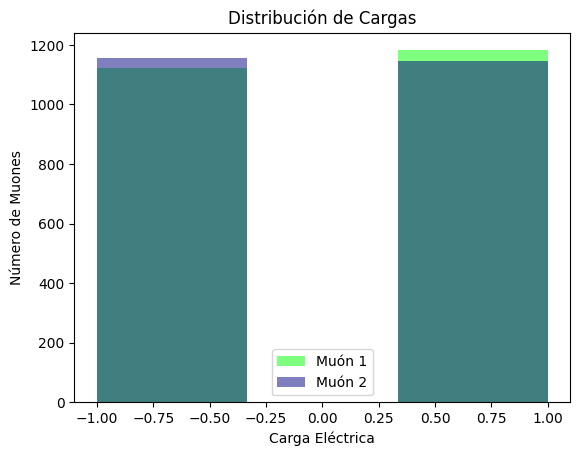

In [ ]:
# cargas

plt.hist(datos["Q1"], bins=3, alpha=0.5, label="Muón 1", color="lime")
plt.hist(datos["Q2"], bins=3, alpha=0.5, label="Muón 2", color="navy")

plt.xlabel("Carga Eléctrica")
plt.ylabel("Número de Muones")
plt.title("Distribución de Cargas")
plt.legend()
plt.show()

In [ ]:
producto_cargas = datos["Q1"] * datos["Q2"]


cargas_opuestas = datos[producto_cargas < 0]


porcentaje = len(cargas_opuestas) * 100 / len(datos)


print("Porcentaje (Pares con Cargas Opuestas) =", porcentaje)

Porcentaje (Pares con Cargas Opuestas) = 93.18576388888889


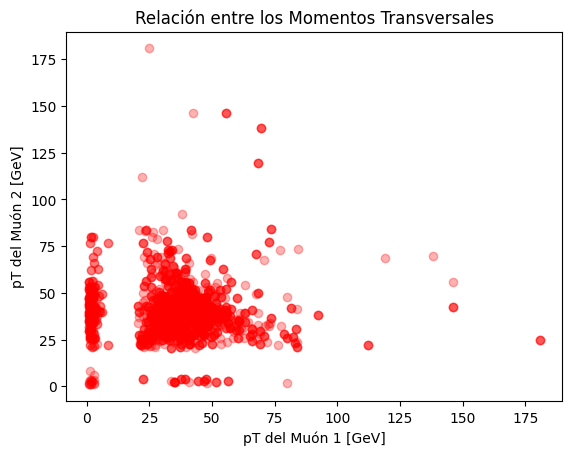

In [ ]:
#momento transversal del muón 1 y muón 2

plt.scatter(datos["pt1"], datos["pt2"], alpha=0.3, color="red")
plt.xlabel("pT del Muón 1 [GeV]")
plt.ylabel("pT del Muón 2 [GeV]")
plt.title("Relación entre los Momentos Transversales")
plt.show()

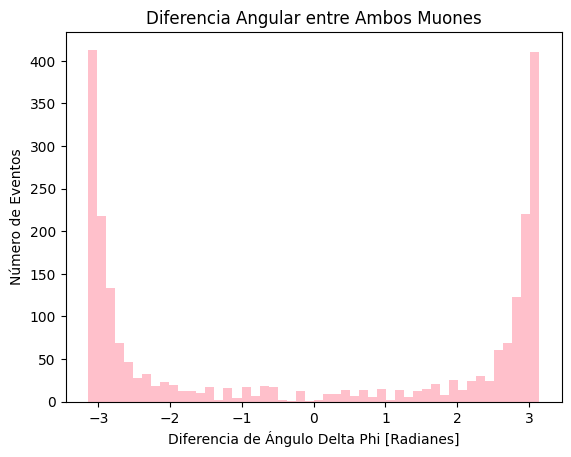

In [ ]:
diferencia_phi = datos["phi1"] - datos["phi2"]
diferencia_phi = np.arctan2(np.sin(diferencia_phi),np.cos(diferencia_phi))

plt.hist(diferencia_phi, bins=50, color="pink")
plt.xlabel("Diferencia de Ángulo Delta Phi [Radianes]")
plt.ylabel("Número de Eventos")
plt.title("Diferencia Angular entre Ambos Muones")
plt.show()

## 5. INTERPRETACIONES